In [1]:
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd

In [2]:
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.roblox.client&hl=id"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.roblox.client


In [5]:
app_reviews, _ = reviews(
    package_name,
    lang='en',   # Language: English
    country='us',  # Country: US
    count=200,   # Fetch 200 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,288b3f9b-b1c3-4f84-a723-aa5963f521d3,K.a mmu,https://play-lh.googleusercontent.com/a/ACg8oc...,i like,5,0,2.659.473,2026-03-29 10:16:42,None,None,2.659.473
1,4fc0da8b-4fc4-4f09-a8b3-a71acf078b6c,flaming Springtrap,https://play-lh.googleusercontent.com/a-/ALV-U...,age verification. removed classic faces.,1,2,2.711.876,2026-03-29 10:15:29,None,None,2.711.876
2,7e28d0cd-08e9-407f-a59d-4881885afcbb,Joan Ocaya,https://play-lh.googleusercontent.com/a-/ALV-U...,I miss roblox bcus a strong typhoon destroyed ...,5,0,None,2026-03-29 10:15:17,None,None,None
3,44ccb0f4-201f-4c12-bfb5-8121941697c3,SMILER,https://play-lh.googleusercontent.com/a-/ALV-U...,1 star is too much,1,0,None,2026-03-29 10:14:53,None,None,None
4,51db7ffd-dff2-444b-b485-a61b3cf349f7,Gavin Paul M Bayron,https://play-lh.googleusercontent.com/a-/ALV-U...,an absolutely greedy company. ever since the s...,1,0,2.713.912,2026-03-29 10:14:36,None,None,2.713.912
...,...,...,...,...,...,...,...,...,...,...,...
195,04adf10c-2fea-4a83-8935-1b1b1fa8fcdc,Criscita Mendoza,https://play-lh.googleusercontent.com/a/ACg8oc...,chat back!!!!!!!!!!!!!!!!!!!!!!!,1,0,None,2026-03-29 07:55:18,None,None,None
196,9234f908-f7a8-4434-a0ae-0ea521281ed9,Israel Gonzalez,https://play-lh.googleusercontent.com/a-/ALV-U...,I used to like roblox but they added a new upd...,1,0,2.702.632,2026-03-29 07:54:21,None,None,2.702.632
197,7db91710-d2bf-47f8-b1bb-7d7e863634db,Jm e merin Jm e merin,https://play-lh.googleusercontent.com/a/ACg8oc...,is cool game but it's kinda lag,5,0,None,2026-03-29 07:53:50,None,None,None
198,02d5ed8e-6c88-4496-b3b7-1cff25c5b44a,littlemadampao Tupas,https://play-lh.googleusercontent.com/a/ACg8oc...,"Okay okay, This is such a DUMB UPDATE!! Like I...",3,131,2.714.1091,2026-03-29 07:53:06,None,None,2.714.1091


In [6]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,288b3f9b-b1c3-4f84-a723-aa5963f521d3,i like,5
1,4fc0da8b-4fc4-4f09-a8b3-a71acf078b6c,age verification. removed classic faces.,1
2,7e28d0cd-08e9-407f-a59d-4881885afcbb,I miss roblox bcus a strong typhoon destroyed ...,5
3,44ccb0f4-201f-4c12-bfb5-8121941697c3,1 star is too much,1
4,51db7ffd-dff2-444b-b485-a61b3cf349f7,an absolutely greedy company. ever since the s...,1
...,...,...,...
195,04adf10c-2fea-4a83-8935-1b1b1fa8fcdc,chat back!!!!!!!!!!!!!!!!!!!!!!!,1
196,9234f908-f7a8-4434-a0ae-0ea521281ed9,I used to like roblox but they added a new upd...,1
197,7db91710-d2bf-47f8-b1bb-7d7e863634db,is cool game but it's kinda lag,5
198,02d5ed8e-6c88-4496-b3b7-1cff25c5b44a,"Okay okay, This is such a DUMB UPDATE!! Like I...",3


In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mengunduh resource NLTK yang dibutuhkan (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inisialisasi lemmatizer dan daftar stopwords bahasa Inggris
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 6. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 10 baris pertama dari hasilnya
output_df.head(10)

[nltk_data] Downloading package stopwords to C:\Users\ASTHAGINA DELIA
[nltk_data]     P\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ASTHAGINA DELIA
[nltk_data]     P\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\ASTHAGINA DELIA
[nltk_data]     P\AppData\Roaming\nltk_data...


,content,cleaned_text
0,i like,like
1,age verification. removed classic faces.,age verification removed classic face
2,I miss roblox bcus a strong typhoon destroyed ...,miss roblox bcus strong typhoon destroyed coun...
3,1 star is too much,star much
4,an absolutely greedy company. ever since the s...,absolutely greedy company ever since start rob...
5,stop making roblox even worse🥀,stop making roblox even worse
6,FIX YOUR DAMN UPDATES,fix damn update
7,IS NOW BORING BECAUSE WE CAN'T TALK NOW AND NO...,boring cant talk normal face gone
8,you need to fix your app I get it that your tr...,need fix app get trying help community chat up...
9,"Awfull, the way Roblox deleted classic face (w...",awfull way roblox deleted classic face icon ro...


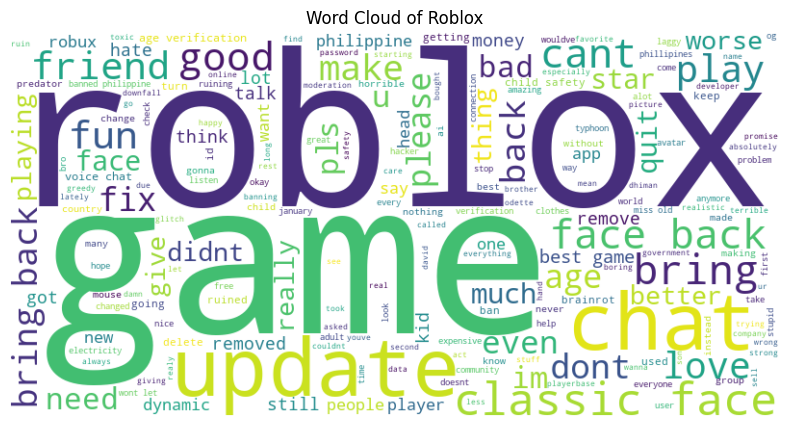

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Roblox")
plt.show()

        Word  Frequency
16      game         98
7     roblox         87
5       face         57
100     back         50
74      chat         38
99     bring         36
15    update         33
0       like         28
4    classic         27
64      cant         21
98      good         20
1        age         19
143   friend         19
158      fun         19
102     play         18
140     love         17
51      make         16
25      dont         14
61       fix         13
175   please         13


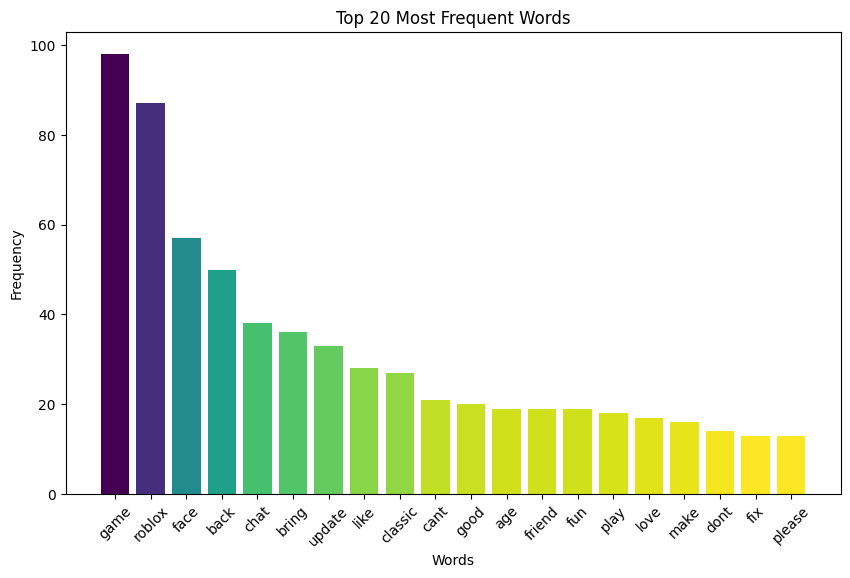

In [17]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# Define TF-IDF vectorizer
# Create a Porter Stemmer tokenizer function
porter_stemmer = PorterStemmer()

def tokenizer_porter(text):
    return [porter_stemmer.stem(word) for word in text.split()]

# Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)
# Fit and transform the cleaned text data
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(200, 639)


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (200, 693)
Dimensi target y: (200,)


In [23]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 160
Jumlah data testing: 40


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression()

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 85.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.96      0.90        28
    Positive       0.88      0.58      0.70        12

    accuracy                           0.85        40
   macro avg       0.86      0.77      0.80        40
weighted avg       0.85      0.85      0.84        40



In [29]:
def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "my cousins really love this game, it's so fun and engaging!"
test_sentence_2 = "Too many ads and it keeps crashing on my phone. Unplayable."

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'my cousins really love this game, it's so fun and engaging!'
Prediksi: Positive

Review: 'Too many ads and it keeps crashing on my phone. Unplayable.'
Prediksi: Negative


In [26]:
# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,i like,5,Positive
1,age verification. removed classic faces.,1,Negative
2,I miss roblox bcus a strong typhoon destroyed ...,5,Positive
3,1 star is too much,1,Negative
4,an absolutely greedy company. ever since the s...,1,Negative


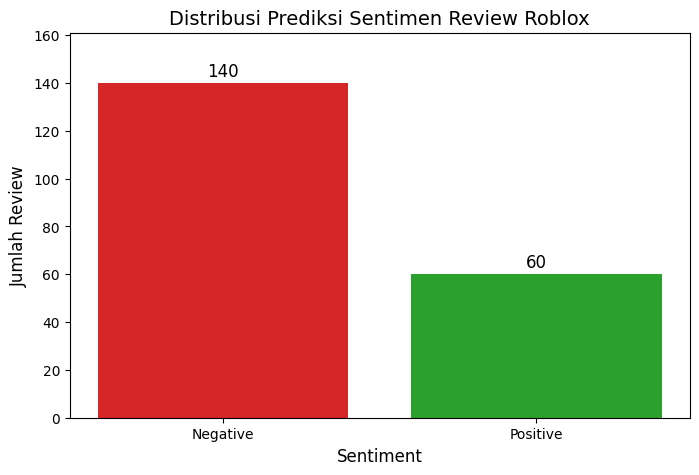

In [33]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#d62728', '#2ca02c'])

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review Roblox', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()